In [1]:
import os
import re
import torch
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data

In [2]:
DATASET_PATH = "/content/drive/MyDrive/nlp_project/data/raw"

texts = []
labels = []

for label_name in os.listdir(DATASET_PATH):

    folder_path = os.path.join(DATASET_PATH, label_name)

    # kiểm tra có phải folder không
    if os.path.isdir(folder_path):

        for file_name in os.listdir(folder_path):

            if file_name.endswith(".txt"):

                file_path = os.path.join(folder_path, file_name)

                try:
                    with open(file_path, "r", encoding="utf-8") as f:

                        text = f.read()

                        texts.append(text)

                        labels.append(label_name)

                except Exception as e:
                    print(f"Error reading {file_name}: {e}")

In [3]:
df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print(df.head())

                                                text   label
0  TIÊU ĐỀ: Giảm xe cá nhân, tăng vận tải công cộ...  xa_hoi
1  TIÊU ĐỀ: Nắng nóng diện rộng ở Trung Bộ, nhiều...  xa_hoi
2  TIÊU ĐỀ: Xây dựng nền báo chí cách mạng vững t...  xa_hoi
3  TIÊU ĐỀ: Độc đáo sắc hoa "bún tươi" bung nở rự...  xa_hoi
4  TIÊU ĐỀ: Dự án đường sắt tốc độ cao Bắc - Nam ...  xa_hoi


In [4]:
df['label'].value_counts()

,count
label,
the_gioi,1068
phap_luat,956
xa_hoi,806
kinh_te,596
y_te,577
thoi_su,572
the_thao,550
truyen_hinh,495
du_lich,356


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256 entries, 0 to 6255
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    6256 non-null   object
 1   label   6256 non-null   object
dtypes: object(2)
memory usage: 97.9+ KB


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6256 entries, 0 to 6255
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    6256 non-null   object
 1   label   6256 non-null   object
dtypes: object(2)
memory usage: 97.9+ KB


In [7]:
df.to_csv('/content/drive/MyDrive/nlp_project/data/processed/data_cleaned_001.csv', index=False)
print('Dataset saved successfully!!!')

Dataset saved successfully!!!


In [8]:
# =========================================================
# TEXT PREPROCESSING
# =========================================================

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove url
    text = re.sub(r"http\S+", "", text)

    # remove html
    text = re.sub(r"<.*?>", " ", text)

    # remove special characters
    text = re.sub(r"[^\w\s]", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [9]:
df.head(10)

,text,label
0,"TIÊU ĐỀ: Giảm xe cá nhân, tăng vận tải công cộ...",xa_hoi
1,"TIÊU ĐỀ: Nắng nóng diện rộng ở Trung Bộ, nhiều...",xa_hoi
2,TIÊU ĐỀ: Xây dựng nền báo chí cách mạng vững t...,xa_hoi
3,"TIÊU ĐỀ: Độc đáo sắc hoa ""bún tươi"" bung nở rự...",xa_hoi
4,TIÊU ĐỀ: Dự án đường sắt tốc độ cao Bắc - Nam ...,xa_hoi
5,"TIÊU ĐỀ: Cần cơ chế bảo tồn, bảo quản bảo vật ...",xa_hoi
6,TIÊU ĐỀ: Hà Nội đẩy nhanh phát triển hạ tầng n...,xa_hoi
7,TIÊU ĐỀ: Nông dân chật vật dưới nắng nóng gay ...,xa_hoi
8,TIÊU ĐỀ: Sách Tin học lớp 3 chứa link nhạy cảm...,xa_hoi
9,"TIÊU ĐỀ: Giữa tháng 5, Quốc lộ 6 qua Mai Châu ...",xa_hoi


In [10]:
df["text"] = df["text"].apply(preprocess_text)

In [11]:
# =========================================================
# LABEL ENCODING
# =========================================================

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

['du_lich' 'kinh_te' 'phap_luat' 'the_gioi' 'the_thao' 'thi_truong'
 'thoi_su' 'truyen_hinh' 'van_hoa' 'xa_hoi' 'y_te']


In [12]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

Train: 5004
Validation: 626
Test: 626


### Check Label Distribution in Train, Validation, and Test Sets

In [13]:
print('Train Labels Distribution:')
print(train_labels.value_counts(normalize=True))
print('\nValidation Labels Distribution:')
print(val_labels.value_counts(normalize=True))
print('\nTest Labels Distribution:')
print(test_labels.value_counts(normalize=True))

Train Labels Distribution:
label
3     0.170663
2     0.152878
9     0.128897
1     0.095324
10    0.092126
6     0.091327
4     0.087930
7     0.079137
0     0.056954
8     0.031974
5     0.012790
Name: proportion, dtype: float64

Validation Labels Distribution:
label
3     0.170927
2     0.151757
9     0.129393
1     0.095847
10    0.092652
6     0.091054
4     0.087859
7     0.078275
0     0.057508
8     0.031949
5     0.012780
Name: proportion, dtype: float64

Test Labels Distribution:
label
3     0.170927
2     0.153355
9     0.127796
1     0.094249
10    0.092652
6     0.092652
4     0.087859
7     0.079872
0     0.055911
8     0.031949
5     0.012780
Name: proportion, dtype: float64


In [14]:
# =========================================================
# LOAD TOKENIZER
# =========================================================

MODEL_NAME = "vinai/phobert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [15]:
# =========================================================
# TOKENIZATION
# =========================================================

MAX_LEN = 256

def tokenize_function(texts):

    return tokenizer(
        texts.tolist(),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )


train_encodings = tokenize_function(train_texts)

val_encodings = tokenize_function(val_texts)

test_encodings = tokenize_function(test_texts)

In [16]:
# =========================================================
# CREATE DATASET
# =========================================================

train_dataset = Dataset.from_dict({
    "input_ids": train_encodings["input_ids"],
    "attention_mask": train_encodings["attention_mask"],
    "labels": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    "input_ids": val_encodings["input_ids"],
    "attention_mask": val_encodings["attention_mask"],
    "labels": val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"],
    "labels": test_labels.tolist()
})

In [17]:
# =========================================================
# LOAD MODEL
# =========================================================

num_labels = df["label"].nunique()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels
)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

In [18]:
# =========================================================
# METRICS
# =========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),

        "precision": precision_score(
            labels,
            predictions,
            average="weighted"
        ),

        "recall": recall_score(
            labels,
            predictions,
            average="weighted"
        ),

        "f1": f1_score(
            labels,
            predictions,
            average="weighted"
        )
    }

In [19]:
# =========================================================
# TRAINING ARGUMENTS
# =========================================================

training_args = TrainingArguments(

    output_dir="./phobert_news_classifier",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1"
)

In [20]:
# =========================================================
# TRAINER
# =========================================================

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

In [21]:
# =========================================================
# TRAIN
# =========================================================

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.092571,0.526123,0.856230,0.865724,0.856230,0.853399
2,0.450788,0.461571,0.875399,0.882328,0.875399,0.875146
3,0.320629,0.437593,0.896166,0.896204,0.896166,0.895758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1878, training_loss=0.544747158615226, metrics={'train_runtime': 872.6673, 'train_samples_per_second': 17.202, 'train_steps_per_second': 2.152, 'total_flos': 1975071168940032.0, 'train_loss': 0.544747158615226, 'epoch': 3.0})

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [22]:
# =========================================================
# TEST
# =========================================================

predictions = trainer.predict(test_dataset)

pred_labels = np.argmax(predictions.predictions, axis=1)

print(classification_report(
    test_labels,
    pred_labels,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

     du_lich       0.83      0.86      0.85        35
     kinh_te       0.87      0.81      0.84        59
   phap_luat       0.88      0.93      0.90        96
    the_gioi       0.94      0.94      0.94       107
    the_thao       1.00      0.96      0.98        55
  thi_truong       1.00      0.75      0.86         8
     thoi_su       0.88      0.62      0.73        58
 truyen_hinh       0.96      0.98      0.97        50
     van_hoa       0.77      0.85      0.81        20
      xa_hoi       0.82      0.93      0.87        80
        y_te       0.89      0.97      0.93        58

    accuracy                           0.89       626
   macro avg       0.90      0.87      0.88       626
weighted avg       0.89      0.89      0.89       626



In [25]:
# =========================================================
# PREDICT NEW ARTICLE
# =========================================================

news = """
Trong những ngày gần đây giá xăng tăng lên quá cao so với ngày thường cho nên tôi không thể đi đâu chơi ngày 30/4.
"""

news = preprocess_text(news)

inputs = tokenizer(
    news,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)

# Move inputs to the same device as the model
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.no_grad():

    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1).item()

predicted_label = label_encoder.inverse_transform([prediction])[0]

print("Predicted label:", predicted_label)

Predicted label: thi_truong


In [26]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [27]:
log_history = trainer.state.log_history

# convert to dataframe
logs_df = pd.DataFrame(log_history)

print(logs_df.head())

       loss  grad_norm  learning_rate     epoch  step  eval_loss  \
0  1.092571  15.946301       0.000015  0.798722   500        NaN   
1       NaN        NaN            NaN  1.000000   626   0.526123   
2  0.450788  44.966900       0.000009  1.597444  1000        NaN   
3       NaN        NaN            NaN  2.000000  1252   0.461571   
4  0.320629  26.256372       0.000004  2.396166  1500        NaN   

   eval_accuracy  eval_precision  eval_recall   eval_f1  eval_runtime  \
0            NaN             NaN          NaN       NaN           NaN   
1       0.856230        0.865724     0.856230  0.853399       10.7317   
2            NaN             NaN          NaN       NaN           NaN   
3       0.875399        0.882328     0.875399  0.875146       10.7479   
4            NaN             NaN          NaN       NaN           NaN   

   eval_samples_per_second  eval_steps_per_second  train_runtime  \
0                      NaN                    NaN            NaN   
1               

In [28]:
train_loss_df = logs_df[
    logs_df["train_loss"].notna()
]

Train Accuracy: 0.9502398081534772
Test Accuracy: 0.8929712460063898


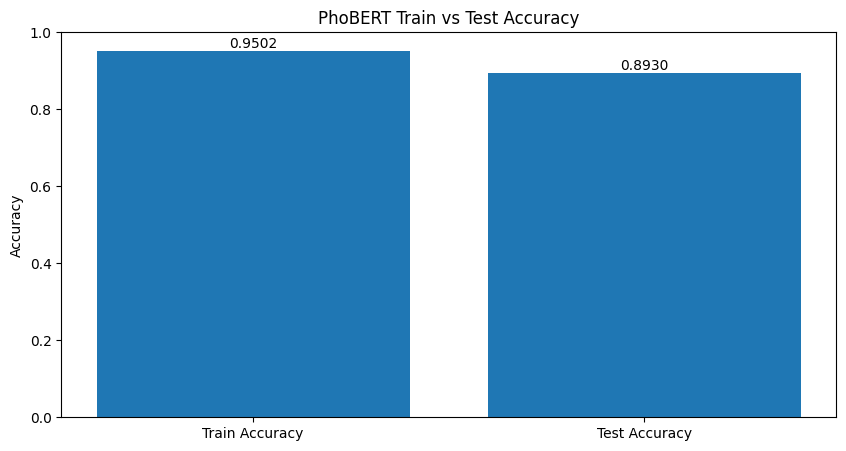

In [29]:
# =========================================================
# 1. TRAIN PREDICTIONS
# =========================================================

train_predictions = trainer.predict(
    train_dataset
)

train_preds = np.argmax(
    train_predictions.predictions,
    axis=1
)

train_true = train_labels.tolist()

train_accuracy = accuracy_score(
    train_true,
    train_preds
)

# =========================================================
# 2. TEST PREDICTIONS
# =========================================================

test_predictions = trainer.predict(
    test_dataset
)

test_preds = np.argmax(
    test_predictions.predictions,
    axis=1
)

test_true = test_labels.tolist()

test_accuracy = accuracy_score(
    test_true,
    test_preds
)

# =========================================================
# 3. PRINT RESULTS
# =========================================================

print("Train Accuracy:", train_accuracy)

print("Test Accuracy:", test_accuracy)

# =========================================================
# 4. VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(

    ["Train Accuracy", "Test Accuracy"],

    [train_accuracy, test_accuracy]
)

plt.ylabel("Accuracy")

plt.title("PhoBERT Train vs Test Accuracy")

plt.ylim(0, 1)

# show values
for i, v in enumerate(
    [train_accuracy, test_accuracy]
):

    plt.text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha="center"
    )

plt.show()

F1-SCORE
Weighted F1-score : 0.8907
Macro F1-score    : 0.8793
Micro F1-score    : 0.8930


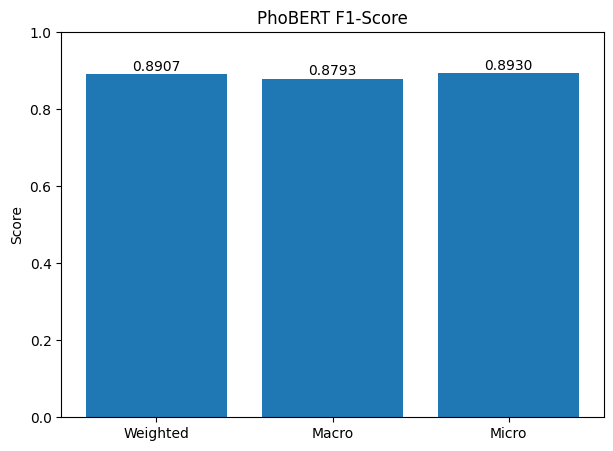

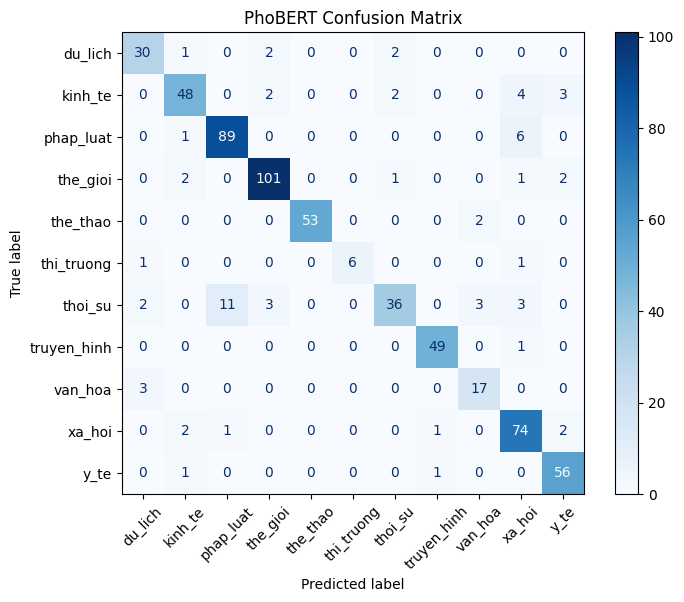

In [30]:
# =========================================================
# PHOBERT CONFUSION MATRIX + F1-SCORE VISUALIZATION
# =========================================================



from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# =========================================================
# 1. PREDICT TEST DATA
# =========================================================

predictions = trainer.predict(
    test_dataset
)

pred_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = test_labels.tolist()

# =========================================================
# 2. CALCULATE F1-SCORE
# =========================================================

f1_weighted = f1_score(

    true_labels,

    pred_labels,

    average="weighted"
)

f1_macro = f1_score(

    true_labels,

    pred_labels,

    average="macro"
)

f1_micro = f1_score(

    true_labels,

    pred_labels,

    average="micro"
)

print("=" * 50)
print("F1-SCORE")
print("=" * 50)

print(f"Weighted F1-score : {f1_weighted:.4f}")

print(f"Macro F1-score    : {f1_macro:.4f}")

print(f"Micro F1-score    : {f1_micro:.4f}")

# =========================================================
# 3. VISUALIZE F1-SCORE
# =========================================================

f1_values = [
    f1_weighted,
    f1_macro,
    f1_micro
]

f1_labels = [
    "Weighted",
    "Macro",
    "Micro"
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    f1_labels,
    f1_values
)

plt.title("PhoBERT F1-Score")

plt.ylabel("Score")

plt.ylim(0, 1)

# show values on bars
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height + 0.01,

        f"{height:.4f}",

        ha="center"
    )

plt.show()

# =========================================================
# 4. CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    true_labels,
    pred_labels
)

# =========================================================
# 5. VISUALIZE CONFUSION MATRIX
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title("PhoBERT Confusion Matrix")

plt.xticks(rotation=45)

plt.show()

Train Loss: 0.544747158615226
Validation Loss: 0.4375929534435272


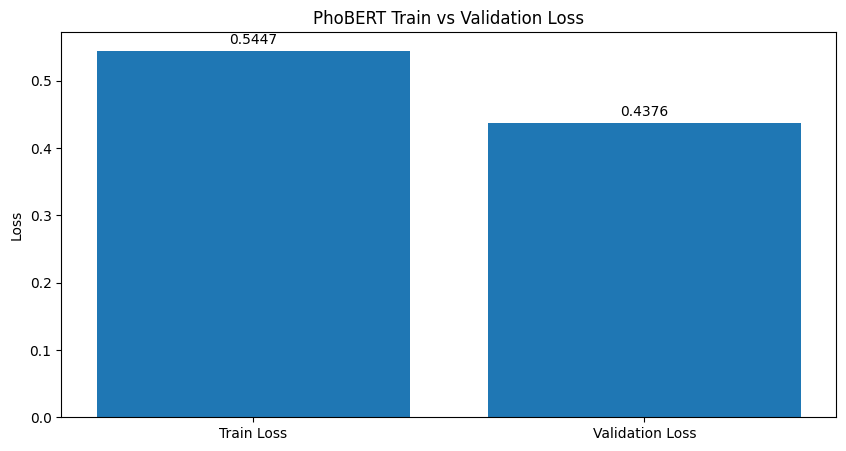

In [31]:
# =========================================================
# TRAIN LOSS VS VALIDATION LOSS
# =========================================================

train_loss = logs_df["train_loss"].dropna().iloc[-1]

eval_loss = logs_df["eval_loss"].dropna().iloc[-1]

print("Train Loss:", train_loss)

print("Validation Loss:", eval_loss)

# =========================================================
# VISUALIZE LOSS
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(

    ["Train Loss", "Validation Loss"],

    [train_loss, eval_loss]
)

plt.ylabel("Loss")

plt.title("PhoBERT Train vs Validation Loss")

for i, v in enumerate(
    [train_loss, eval_loss]
):

    plt.text(
        i,
        v + 0.01,
        f"{v:.4f}",
        ha="center"
    )

plt.show()

In [2]:
from datetime import datetime
import os

# =========================================================
# LOGGING SETUP
# =========================================================

# Create a timestamped directory for logs
LOG_FOLDER_BASE = "/content/drive/MyDrive/nlp_project/logs"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_DIR = os.path.join(LOG_FOLDER_BASE, TIMESTAMP)
os.makedirs(LOG_DIR, exist_ok=True)

# Define the log file path
LOG_FILE_PATH = os.path.join(LOG_DIR, "training_log.txt")

# Open the log file for writing
log_file = open(LOG_FILE_PATH, "w", encoding="utf-8")

print(f"Log directory created: {LOG_DIR}")
print(f"Log file created: {LOG_FILE_PATH}")

# You can now write to `log_file` using `log_file.write()`

Log directory created: /content/drive/MyDrive/nlp_project/logs/20260502_055145
Log file created: /content/drive/MyDrive/nlp_project/logs/20260502_055145/training_log.txt
